## Environment Setup and Imports

The required libraries are imported to load the trained regression pipelines, generate predictions, calculate evaluation metrics, and compare model performance.

The comparison focuses on Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Load Evaluation Dataset

The testing features and target values are loaded from the prepared dataset split.

Using the same test set for all regression models ensures that their performance can be compared under identical evaluation conditions.

In [2]:
x_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Testing features shape:", x_test.shape)
print("Testing target shape:", y_test.shape)

print("\nTesting features:")
display(x_test.head())

print("\nTesting target:")
display(y_test.head())

Testing features shape: (3366, 6)
Testing target shape: (3366,)

Testing features:


,Locality,Latitude,Longitude,Signal Strength (dBm),Latency (ms),Network Type
0,Anisabad,25.726280,85.079655,-88.480745,17.376201,5G
1,Exhibition Road,25.463564,85.152798,-91.032814,67.273238,4G
2,Gandhi Maidan,25.487188,85.138136,-85.620351,73.451172,4G
3,Kankarbagh,25.690184,85.254868,-82.582479,190.053481,3G
4,Gandhi Maidan,25.500215,84.989757,-85.654623,62.809294,4G



Testing target:


0    59.288426
1     9.045216
2     5.414390
3     1.215062
4     3.782074
Name: Data Throughput (Mbps), dtype: float64

## Load Trained Regression Pipelines

The trained regression pipelines are loaded from the models directory.

Each pipeline contains the preprocessing and trained regression model required to generate predictions from the original feature representation.

In [3]:
model_paths = {
    "Linear Regression": "../models/linear_regression.joblib",
    "KNN": "../models/knn.joblib",
    "SVR": "../models/svr.joblib",
    "Random Forest": "../models/random_forest.joblib",
    "XGBoost": "../models/xgboost.joblib"
}

models = {}

for model_name, model_path in model_paths.items():
    models[model_name] = joblib.load(model_path)

print("Loaded models:")

for model_name in models:
    print(f"- {model_name}")

Loaded models:
- Linear Regression
- KNN
- SVR
- Random Forest
- XGBoost


## Generate Model Predictions

Predictions are generated for the same testing dataset using each trained regression pipeline.

Using a common test set allows the models to be evaluated and compared consistently.

In [4]:
predictions = {}

for model_name, model in models.items():
    predictions[model_name] = model.predict(x_test)

print("Predictions generated successfully.")

for model_name, prediction in predictions.items():
    print(
        f"{model_name}: "
        f"{prediction.shape}"
    )

Predictions generated successfully.
Linear Regression: (3366, 1)
KNN: (3366,)
SVR: (3366,)
Random Forest: (3366,)
XGBoost: (3366,)


## Standardize Prediction Shapes

The prediction outputs are standardized into one-dimensional arrays to ensure consistent metric calculations across all regression models.

In [5]:
predictions = {
    model_name: np.asarray(prediction).ravel()
    for model_name, prediction in predictions.items()
}

print("Standardized prediction shapes:")

for model_name, prediction in predictions.items():
    print(f"{model_name}: {prediction.shape}")

Standardized prediction shapes:
Linear Regression: (3366,)
KNN: (3366,)
SVR: (3366,)
Random Forest: (3366,)
XGBoost: (3366,)


## Evaluate Regression Models

Each regression model is evaluated on the same testing dataset using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

These metrics provide complementary views of prediction accuracy and allow the models to be compared under identical conditions.

In [6]:
results = []

for model_name, prediction in predictions.items():
    mae = mean_absolute_error(y_test, prediction)
    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

results_df = pd.DataFrame(results)

print("Model Performance Comparison:")
display(results_df.round(4))

Model Performance Comparison:


,Model,MAE,RMSE,R²
0,Linear Regression,6.8287,13.3191,0.7363
1,KNN,6.6088,13.4226,0.7322
2,SVR,6.5950,13.3597,0.7347
3,Random Forest,6.4640,13.3387,0.7355
4,XGBoost,6.4581,13.3298,0.7359


## Rank Models by Prediction Error

The regression models are ranked according to their Mean Absolute Error (MAE).

A lower MAE indicates that the model produces smaller average absolute prediction errors on the testing dataset.

In [7]:
ranked_results = (
    results_df
    .sort_values(by="MAE", ascending=True)
    .reset_index(drop=True)
)

ranked_results.index = ranked_results.index + 1

print("Ranked Model Performance:")
display(ranked_results.round(4))

Ranked Model Performance:


,Model,MAE,RMSE,R²
1,XGBoost,6.4581,13.3298,0.7359
2,Random Forest,6.4640,13.3387,0.7355
3,SVR,6.5950,13.3597,0.7347
4,KNN,6.6088,13.4226,0.7322
5,Linear Regression,6.8287,13.3191,0.7363


## Visualize Model MAE Comparison

The Mean Absolute Error of each regression model is visualized to provide a direct comparison of prediction accuracy.

Lower MAE values indicate better predictive performance.

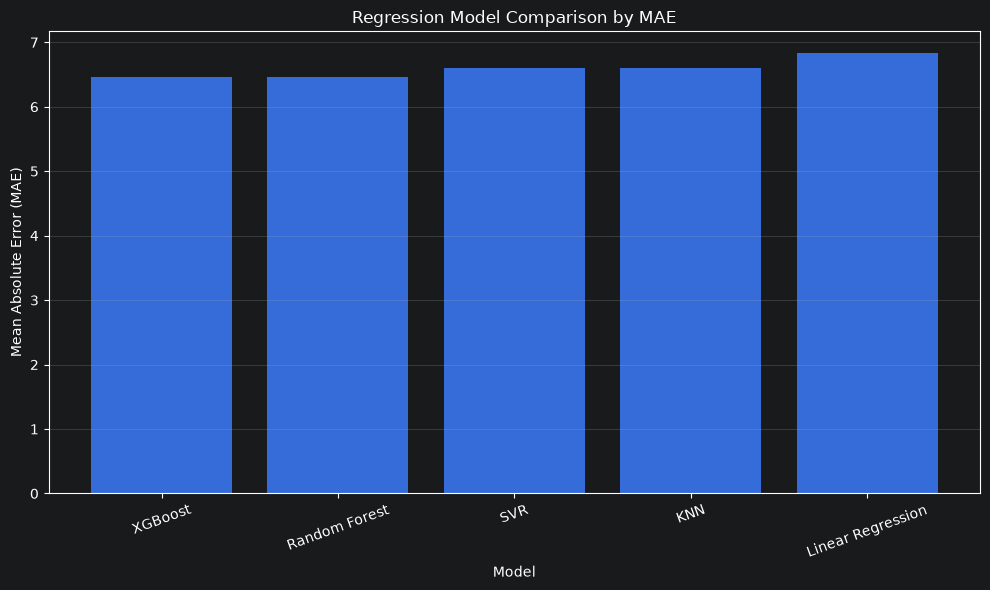

In [8]:
plt.figure(figsize=(10, 6))

plt.bar(
    ranked_results["Model"],
    ranked_results["MAE"]
)

plt.title("Regression Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (MAE)")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Visualize Model RMSE Comparison

The Root Mean Squared Error of each regression model is visualized to compare the magnitude of prediction errors while giving greater weight to larger errors.

Lower RMSE values indicate better predictive performance.

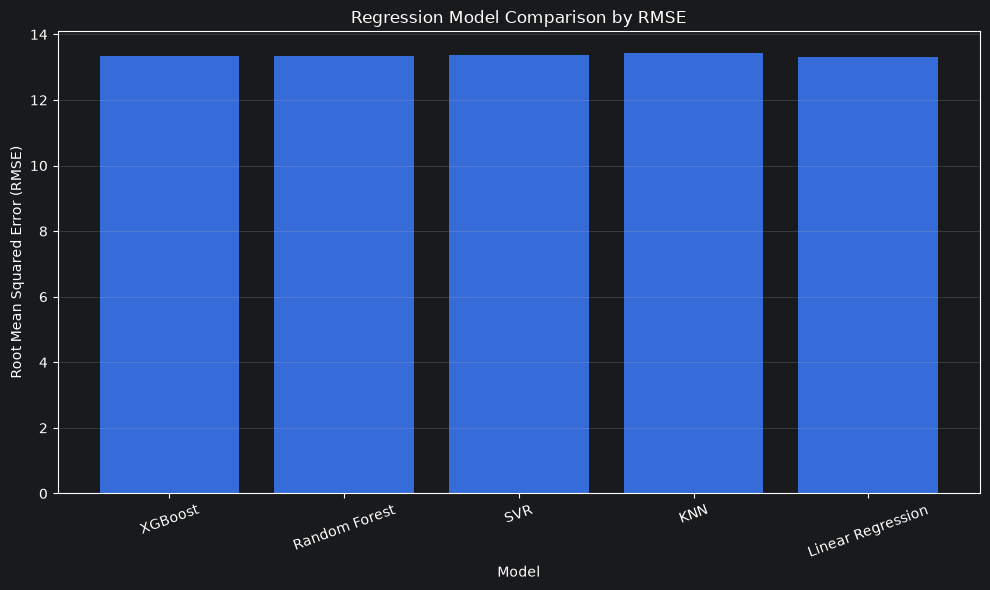

In [9]:
plt.figure(figsize=(10, 6))

plt.bar(
    ranked_results["Model"],
    ranked_results["RMSE"]
)

plt.title("Regression Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Visualize Model R² Comparison

The R² score of each regression model is visualized to compare how effectively the models explain the variation in network throughput.

Higher R² values indicate stronger predictive performance.

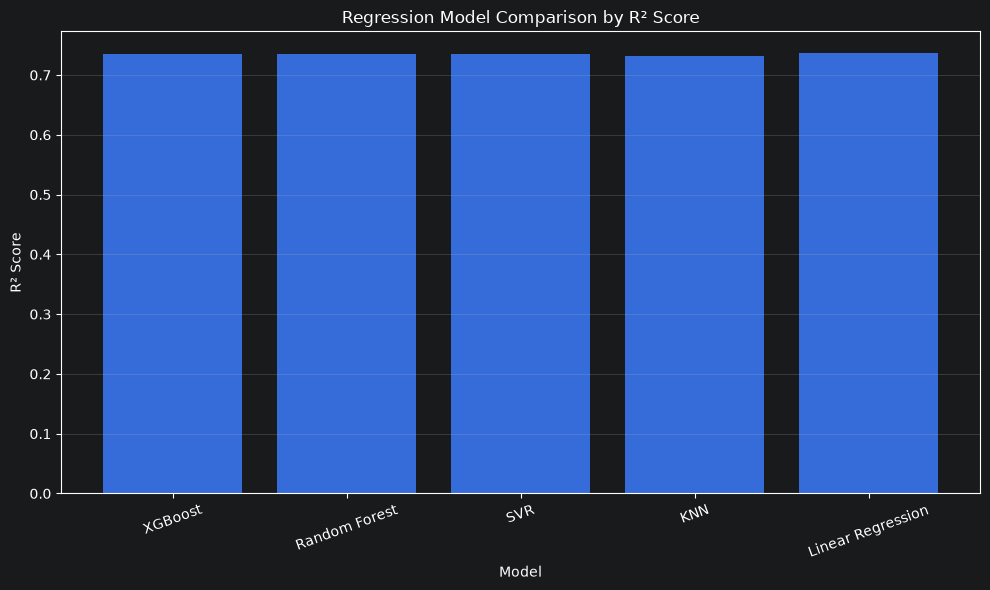

In [10]:
plt.figure(figsize=(10, 6))

plt.bar(
    ranked_results["Model"],
    ranked_results["R²"]
)

plt.title("Regression Model Comparison by R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Select the Best Regression Model

The final regression model is selected based on the lowest Mean Absolute Error (MAE) on the testing dataset.

MAE is used as the primary selection criterion because it directly represents the average absolute prediction error in the target variable's original unit.

In [11]:
best_model_row = ranked_results.iloc[0]

best_model_name = best_model_row["Model"]
best_mae = best_model_row["MAE"]
best_rmse = best_model_row["RMSE"]
best_r2 = best_model_row["R²"]

print("Best Regression Model")
print("--------------------")
print(f"Model : {best_model_name}")
print(f"MAE   : {best_mae:.4f}")
print(f"RMSE  : {best_rmse:.4f}")
print(f"R²    : {best_r2:.4f}")

Best Regression Model
--------------------
Model : XGBoost
MAE   : 6.4581
RMSE  : 13.3298
R²    : 0.7359


## Prepare Final Model Comparison Table

A final comparison table is prepared to summarize the performance of all regression models using MAE, RMSE, and R².

The table provides a concise overview of model performance and highlights the selected model for deployment.

In [12]:
final_comparison = ranked_results.copy()

final_comparison.insert(
    0,
    "Rank",
    range(1, len(final_comparison) + 1)
)

final_comparison["MAE"] = final_comparison["MAE"].round(4)
final_comparison["RMSE"] = final_comparison["RMSE"].round(4)
final_comparison["R²"] = final_comparison["R²"].round(4)

print("Final Regression Model Comparison:")
display(final_comparison)

Final Regression Model Comparison:


,Rank,Model,MAE,RMSE,R²
1,1,XGBoost,6.4581,13.3298,0.7359
2,2,Random Forest,6.4640,13.3387,0.7355
3,3,SVR,6.5950,13.3597,0.7347
4,4,KNN,6.6088,13.4226,0.7322
5,5,Linear Regression,6.8287,13.3191,0.7363


## Save Model Comparison Results

The final model comparison results are saved as a CSV file so they can be reused by the deployment application and other project components without manually reproducing the evaluation results.

In [13]:
comparison_path = "../data/processed/model_comparison.csv"

final_comparison.to_csv(
    comparison_path,
    index=False
)

print(
    f"Model comparison results saved successfully to: {comparison_path}"
)

Model comparison results saved successfully to: ../data/processed/model_comparison.csv
